# 05. 연간 운영 안정성 검토 (요구사항 6)

3일 hourly 예측 이후는 **일 단위 예측**으로 연간 운영의 안정성을 검토합니다. 학습된 정책을 1년(8760h) 동안 굴려

* 월별 밴드 준수율, 홍수·가뭄 시간, 하류 초과 시간
* 건조년 / 평년 / 습윤년(유입량 ×0.6 / ×1.0 / ×1.4)
* 운영자 선호 3가지
* 규칙 베이스라인 대비

를 확인합니다. 정책은 매 시각 72h hourly 예측과 4–10일 daily 예측을 함께 봅니다(관측 `daily_fc_mean_7d`).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
import hourly_reservoir as hr, ppo_lagrangian as pl
plt.rcParams["figure.figsize"] = (12, 3.4)
pd.set_option("display.width", 180)
model, env_kwargs = pl.load_policy("models/policy.pt")
agent = pl.PolicyAgent(model, greedy=True)
env = hr.HourlyReservoirEnv(**env_kwargs)

## 1. 연간 시뮬레이션 격자: 습윤도 × 운영자 선호 × (정책, 규칙)

In [2]:
rows, logs = [], {}
for wet, wlab in ((0.6, "dry"), (1.0, "normal"), (1.4, "wet")):
    for tp in (0.2, 0.5, 0.8):
        for name, pol in (("policy", agent), ("rule", hr.TargetTrackingRule(env))):
            log = hr.run_episode(env, pol, seed=21, start_doy=0, horizon_hours=8760, target_position=tp, wetness=wet)
            logs[(wlab, tp, name)] = log
            s = hr.summarize(log); s["year"], s["target_position"], s["controller"] = wlab, tp, name
            rows.append(s)
res = pd.DataFrame(rows)
key = ["flood_hours_above_upper", "hours_above_design_flood", "downstream_over_capacity_hours", "drought_hours_below_lower",
       "env_flow_violation_hours", "band_compliance_pct", "mean_abs_target_dev_m", "ramp_over_limit_hours", "energy_GWh"]
res.set_index(["year", "target_position", "controller"])[key].round(1)

flood_hours_above_upper  hours_above_design_flood  downstream_over_capacity_hours  drought_hours_below_lower  env_flow_violation_hours  \
year   target_position controller                                                                                                                                           
dry    0.2             policy                          0.0                       0.0                             0.0                       31.0                       0.0   
                       rule                            0.0                       0.0                             0.0                       61.0                       0.0   
       0.5             policy                          0.0                       0.0                             0.0                        0.0                       0.0   
                       rule                            0.0                       0.0                             0.0                        7.0                       0.0   
       0.8             policy                          0.0                       0.0                             0.0                        0.0                       0.0   
                       rule                            0.0                       0.0                             0.0                        0.0                       0.0   
normal 0.2             policy                         17.0                       0.0                             0.0                       63.0                       0.0   
                       rule                            0.0                       0.0                             2.0                       78.0                       0.0   
       0.5             policy                         18.0                       0.0                             0.0                       18.0                       0.0   
                       rule                           22.0                       0.0                             3.0                       13.0                       0.0   
       0.8             policy                         15.0                       0.0                             0.0                       15.0                       0.0   
                       rule                           95.0                       0.0                             3.0                        0.0                       0.0   
wet    0.2             policy                         72.0                       0.0                             2.0                       75.0                       7.0   
                       rule                          100.0                       0.0                             4.0                       86.0                       7.0   
       0.5             policy                         75.0                       0.0                             2.0                       23.0                       7.0   
                       rule                          111.0                       0.0                             4.0                       18.0                       7.0   
       0.8             policy                         57.0                       0.0                             3.0                       16.0                       7.0   
                       rule                          183.0                       0.0                             4.0                        6.0                       7.0   

                                   band_compliance_pct  mean_abs_target_dev_m  ramp_over_limit_hours  energy_GWh  
year   target_position controller                                                                                 
dry    0.2             policy                     99.6                    0.2                    0.0       222.9  
                       rule                       99.3                    0.1                    1.0       226.3  
       0.5             policy                    100.0                    0.6                    0.0       217.3  

In [3]:
# priority-ordered comparison: policy minus rule (negative = policy better for violation counts)
piv = res.set_index(["year", "target_position", "controller"])[key].unstack("controller")
diff = (piv.xs("policy", axis=1, level=1) - piv.xs("rule", axis=1, level=1)).round(1)
diff

flood_hours_above_upper  hours_above_design_flood  downstream_over_capacity_hours  drought_hours_below_lower  env_flow_violation_hours  \
year   target_position                                                                                                                                           
dry    0.2                                  0.0                       0.0                             0.0                      -30.0                       0.0   
       0.5                                  0.0                       0.0                             0.0                       -7.0                       0.0   
       0.8                                  0.0                       0.0                             0.0                        0.0                       0.0   
normal 0.2                                 17.0                       0.0                            -2.0                      -15.0                       0.0   
       0.5                                 -4.0                       0.0                            -3.0                        5.0                       0.0   
       0.8                                -80.0                       0.0                            -3.0                       15.0                       0.0   
wet    0.2                                -28.0                       0.0                            -2.0                      -11.0                       0.0   
       0.5                                -36.0                       0.0                            -2.0                        5.0                       0.0   
       0.8                               -126.0                       0.0                            -1.0                       10.0                       0.0   

                        band_compliance_pct  mean_abs_target_dev_m  ramp_over_limit_hours  energy_GWh  
year   target_position                                                                                 
dry    0.2                              0.3                    0.1                   -1.0        -3.4  
       0.5                              0.1                    0.5                    0.0        -4.8  
       0.8                              0.0                    0.1                    0.0         0.2  
normal 0.2                             -0.0                    0.3                   -3.0       -11.9  
       0.5                             -0.0                    0.5                   -2.0       -15.5  
       0.8                              0.7                    0.2                   -4.0       -10.5  
wet    0.2                              0.4                    0.4                   -9.0       -29.2  
       0.5                              0.4                    0.5                   -8.0       -35.8  
       0.8                              1.3                    0.4                   -5.0       -38.4

## 2. 연간 수위 궤적 (평년, 선호 3가지)

Text(0.5, 0, 'day of year')

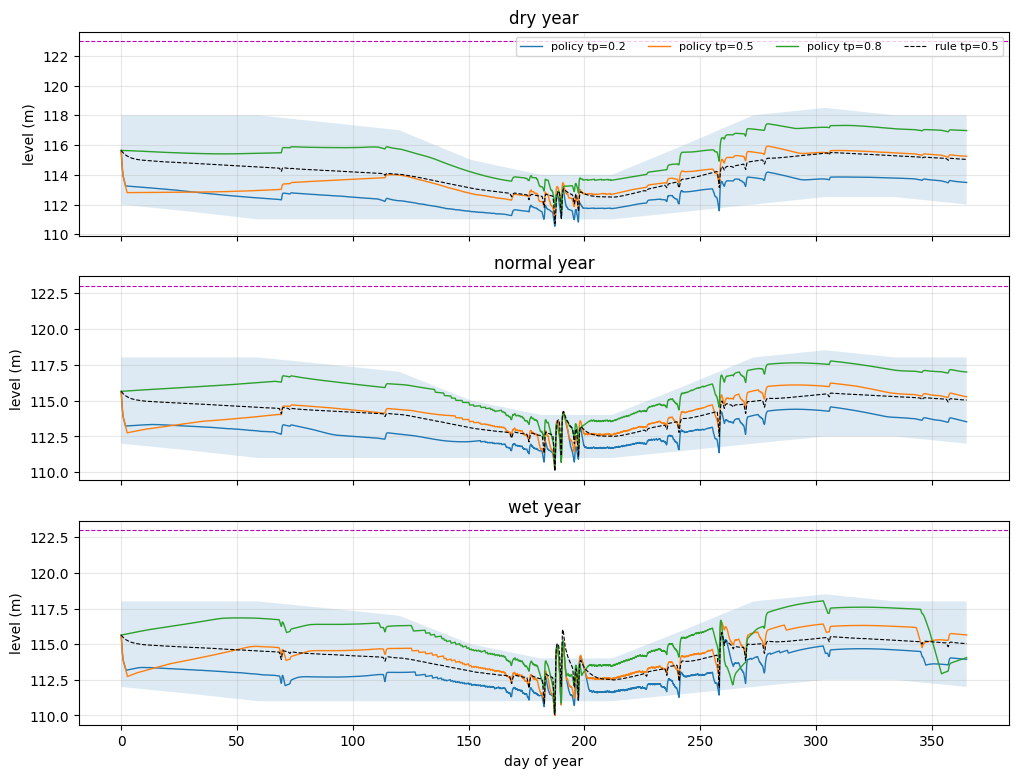

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, wlab in zip(axes, ("dry", "normal", "wet")):
    lg = logs[(wlab, 0.5, "policy")]
    ax.fill_between(lg.doy, lg.lower, lg.upper, alpha=.15)
    for tp in (0.2, 0.5, 0.8):
        ax.plot(logs[(wlab, tp, "policy")].doy, logs[(wlab, tp, "policy")].level, lw=1, label=f"policy tp={tp}")
    ax.plot(logs[(wlab, 0.5, "rule")].doy, logs[(wlab, 0.5, "rule")].level, "k--", lw=.8, label="rule tp=0.5")
    ax.axhline(hr.Z_DESIGN_FLOOD, c="m", ls="--", lw=.8); ax.set_ylabel("level (m)"); ax.set_title(f"{wlab} year"); ax.grid(alpha=.3)
axes[0].legend(ncol=4, fontsize=8); axes[-1].set_xlabel("day of year")

## 3. 월별 안정성 표 (평년, 중간 운영)

매월 1일 기준 밴드가 바뀌므로 월별로 준수율과 위반 시간을 봅니다. 이 표가 연간 운영계획 검토 회의의 기본 자료가 됩니다.

In [5]:
def monthly_table(log):
    m = pd.cut(log.doy % 365, bins=np.append(hr.MONTH_START_DOY, 365), labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], right=False)
    g = log.groupby(m, observed=True)
    return pd.DataFrame({
        "mean_level": g.level_next.mean(), "upper": g.upper.mean(), "lower": g.lower.mean(),
        "band_pct": g.apply(lambda d: 100 * ((d.level_next <= d.upper) & (d.level_next >= d.lower)).mean()),
        "flood_h": g.apply(lambda d: int((d.level_next > d.upper).sum())),
        "drought_h": g.apply(lambda d: int((d.level_next < d.lower).sum())),
        "ds_over_h": g.apply(lambda d: int((d.ds_flow > hr.Q_DS_SAFE).sum())),
        "max_inflow": g.inflow.max(), "mean_release": g.release.mean(), "energy_GWh": g.power_mw.sum() / 1000,
    }).round(1)

monthly_table(logs[("normal", 0.5, "policy")])

,mean_level,upper,lower,band_pct,flood_h,drought_h,ds_over_h,max_inflow,mean_release,energy_GWh
doy,,,,,,,,,,
Jan,113.2,118.0,111.8,100.0,0,0,0,33.1,72.5,13.4
Feb,113.7,118.0,111.3,100.0,0,0,0,35.7,25.6,7.4
Mar,114.4,117.8,111.0,100.0,0,0,0,967.2,41.3,13.4
Apr,114.3,117.3,111.0,100.0,0,0,0,460.2,56.2,17.7
May,114.0,116.0,111.0,100.0,0,0,0,79.5,80.0,25.1
Jun,113.0,114.5,111.0,100.0,0,0,0,978.8,153.7,40.4
Jul,112.5,114.0,111.0,95.2,18,18,0,5413.2,365.9,67.0
Aug,113.3,115.0,111.2,100.0,0,0,0,1612.6,157.1,43.2
Sep,114.7,117.0,111.7,100.0,0,0,0,4410.4,179.2,43.0


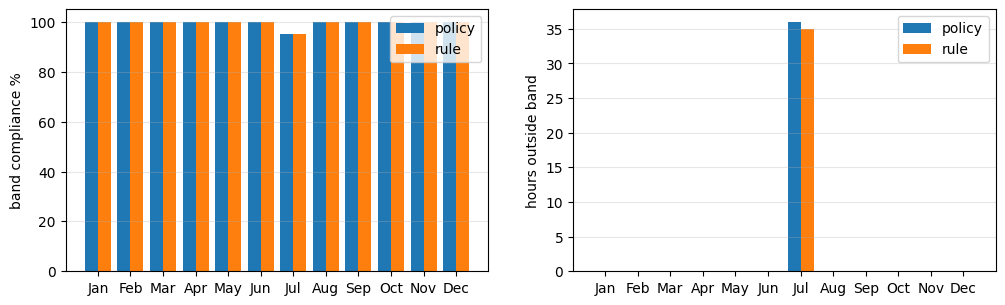

In [6]:
mt_p, mt_r = monthly_table(logs[("normal", 0.5, "policy")]), monthly_table(logs[("normal", 0.5, "rule")])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
x = np.arange(12)
axes[0].bar(x - .2, mt_p.band_pct, .4, label="policy"); axes[0].bar(x + .2, mt_r.band_pct, .4, label="rule"); axes[0].set_xticks(x, mt_p.index); axes[0].set_ylabel("band compliance %"); axes[0].legend(); axes[0].set_ylim(0, 105)
axes[1].bar(x - .2, mt_p.flood_h + mt_p.drought_h, .4, label="policy"); axes[1].bar(x + .2, mt_r.flood_h + mt_r.drought_h, .4, label="rule"); axes[1].set_xticks(x, mt_r.index); axes[1].set_ylabel("hours outside band"); axes[1].legend()
for a in axes: a.grid(alpha=.3, axis="y")

## 4. 예측 오차 민감도

일 단위 예측 오차를 45% → 80% 로 키웠을 때 연간 지표가 얼마나 나빠지는지 확인합니다. 정책이 예측에 과도하게 의존하면 여기서 드러납니다.

In [7]:
rows = []
for dsig in (0.2, 0.45, 0.8):
    for hsig in ((0.05, 0.2), (0.08, 0.35), (0.15, 0.6)):
        e = hr.HourlyReservoirEnv(**env_kwargs)
        obs, info = e.reset(seed=21, start_doy=0, horizon_hours=8760, target_position=0.5)
        e.hourly_fc, e.daily_fc = hr.make_forecasts(e.inflow, seed=5, hourly_sigma=hsig, daily_sigma=dsig)
        info["action_mask"] = e.action_mask(); done = False
        while not done:
            obs, r, te, tr, info = e.step(agent(obs, info["action_mask"])); done = te or tr
        s = hr.summarize(pd.DataFrame(e.history)); s["daily_sigma"], s["hourly_sigma_72h"] = dsig, hsig[1]; rows.append(s)
pd.DataFrame(rows).set_index(["daily_sigma", "hourly_sigma_72h"])[["flood_hours_above_upper", "downstream_over_capacity_hours", "drought_hours_below_lower", "band_compliance_pct", "mean_abs_target_dev_m"]].round(1)

flood_hours_above_upper  downstream_over_capacity_hours  drought_hours_below_lower  band_compliance_pct  mean_abs_target_dev_m
daily_sigma hourly_sigma_72h                                                                                                                                
0.20        0.20                                 21.0                             1.0                       17.0                 99.6                    0.6
            0.35                                 12.0                             1.0                       20.0                 99.6                    0.6
            0.60                                  0.0                             1.0                       23.0                 99.7                    0.6
0.45        0.20                                 21.0                             1.0                       17.0                 99.6                    0.6
            0.35                                 13.0                             1.0                       20.0                 99.6                    0.6
            0.60                                  0.0                             1.0                       22.0                 99.7                    0.6
0.80        0.20                                 21.0                             1.0                       17.0                 99.6                    0.6
            0.35                                 13.0                             1.0                       20.0                 99.6                    0.6
            0.60                                  0.0                             1.0                       22.0                 99.7                    0.6

## 5. 검토 결론 작성 요령

연간 안정성 검토 보고서에는 다음을 포함합니다.

1. **우선순위 순 지표**: 계획홍수위 초과 시간(0 이어야 함) → 하류 계획홍수량 초과 시간 → 하한 이하 시간 → 밴드 준수율 → 발전량(참고).
2. **건조/평년/습윤년** 모두에서 규칙 대비 위반 시간이 늘지 않았는지(§1 의 `diff` 표).
3. **월별 표**: 밴드 전환기(5–6월 하강, 9–10월 상승)에서 위반이 집중되면 운영수위 곡선 자체의 검토가 필요합니다.
4. **예측 민감도**: 예측 오차가 커져도 홍수 지표가 유지되는지.
5. 위 조건을 만족하지 못하면 노트북 03 의 임계값(`thresholds`)을 낮추거나 반복 수를 늘려 재학습합니다.